# Telco Customer Churn Prediction using Random Forest

## Objective
Implement a Random Forest Classifier to predict customer churn and evaluate it using standard classification metrics.

## Step 1: Import Required Libraries

In [11]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Libraries imported successfully!")

Libraries imported successfully!


## Step 2: Load the Processed Dataset

In [12]:
# Load the processed dataset
df = pd.read_csv('telco_churn_processed.csv')

print("Dataset loaded successfully!")
print(f"Dataset shape: {df.shape}")
print(f"\nFirst few rows:")
df.head()

Dataset loaded successfully!
Dataset shape: (7043, 46)

First few rows:


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Female,gender_Male,Partner_No,Partner_Yes,Dependents_No,Dependents_Yes,...,Contract_Month-to-month,Contract_One year,Contract_Two year,PaperlessBilling_No,PaperlessBilling_Yes,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Churn
0,-0.439916,-1.277445,-1.160323,-0.994242,True,False,False,True,True,False,...,True,False,False,False,True,False,False,True,False,0
1,-0.439916,0.066327,-0.259629,-0.173244,False,True,True,False,True,False,...,False,True,False,True,False,False,False,False,True,0
2,-0.439916,-1.236724,-0.362660,-0.959674,False,True,True,False,True,False,...,True,False,False,False,True,False,False,False,True,1
3,-0.439916,0.514251,-0.746535,-0.194766,False,True,True,False,True,False,...,False,True,False,True,False,True,False,False,False,0
4,-0.439916,-1.236724,0.197365,-0.940470,True,False,True,False,True,False,...,True,False,False,False,True,False,False,True,False,1


## Step 3: Separate Features and Target

In [13]:
# Separate features (X) and target variable (y)
X = df.drop('Churn', axis=1)
y = df['Churn']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nTarget distribution:")
print(y.value_counts())

Features shape: (7043, 45)
Target shape: (7043,)

Target distribution:
Churn
0    5174
1    1869
Name: count, dtype: int64


## Step 4: Split Dataset into Training and Testing Sets

In [14]:
# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

print("Dataset split completed!")
print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")

Dataset split completed!
Training set size: 5634 samples
Testing set size: 1409 samples


## Step 5: Train Random Forest Classifier

In [15]:
# Initialize and train the Random Forest Classifier
rf_classifier = RandomForestClassifier(random_state=42)
print("Training Random Forest Classifier...")
rf_classifier.fit(X_train, y_train)
print("Model training completed!")

Training Random Forest Classifier...
Model training completed!


## Step 6: Make Predictions

In [16]:
# Make predictions on the test set
y_pred = rf_classifier.predict(X_test)
print("Predictions generated successfully!")

Predictions generated successfully!


## Step 7: Evaluate Model Performance

### 7.1 Accuracy Score

In [17]:
# Calculate accuracy score
accuracy = accuracy_score(y_test, y_pred)
print("="*60)
print("MODEL EVALUATION RESULTS")
print("="*60)
print(f"\nAccuracy Score: {accuracy:.4f} ({accuracy*100:.2f}%)")

MODEL EVALUATION RESULTS

Accuracy Score: 0.7963 (79.63%)


### 7.2 Confusion Matrix

In [18]:
# Calculate confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("\n" + "="*60)
print("Confusion Matrix:")
print("="*60)
print(cm)
print("\nInterpretation:")
print(f"True Negatives (Correctly predicted Retained): {cm[0][0]}")
print(f"False Positives (Incorrectly predicted Churned): {cm[0][1]}")
print(f"False Negatives (Incorrectly predicted Retained): {cm[1][0]}")
print(f"True Positives (Correctly predicted Churned): {cm[1][1]}")


Confusion Matrix:
[[945  91]
 [196 177]]

Interpretation:
True Negatives (Correctly predicted Retained): 945
False Positives (Incorrectly predicted Churned): 91
False Negatives (Incorrectly predicted Retained): 196
True Positives (Correctly predicted Churned): 177


### 7.3 Classification Report

In [19]:
# Generate classification report
print("\n" + "="*60)
print("Classification Report:")
print("="*60)
class_names = ['Retained (0)', 'Churned (1)']
print(classification_report(y_test, y_pred, target_names=class_names))
print("="*60)


Classification Report:
              precision    recall  f1-score   support

Retained (0)       0.83      0.91      0.87      1036
 Churned (1)       0.66      0.47      0.55       373

    accuracy                           0.80      1409
   macro avg       0.74      0.69      0.71      1409
weighted avg       0.78      0.80      0.78      1409



## Step 8: Visualize Confusion Matrix

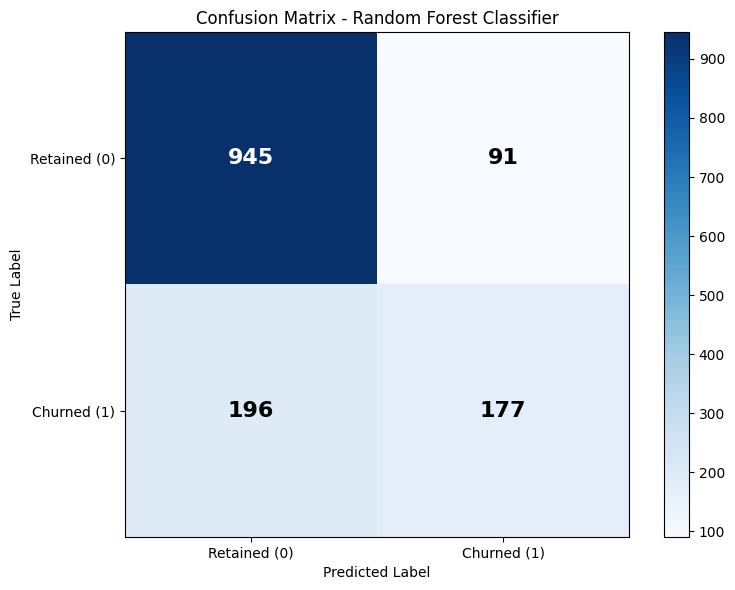


Confusion Matrix plot displayed successfully!


In [20]:
# Plot confusion matrix using matplotlib
fig, ax = plt.subplots(figsize=(8, 6))

# Create the confusion matrix plot
im = ax.imshow(cm, interpolation='nearest', cmap='Blues')
ax.figure.colorbar(im, ax=ax)

# Set labels and title
ax.set(xticks=np.arange(cm.shape[1]),
       yticks=np.arange(cm.shape[0]),
       xticklabels=['Retained (0)', 'Churned (1)'],
       yticklabels=['Retained (0)', 'Churned (1)'],
       ylabel='True Label',
       xlabel='Predicted Label',
       title='Confusion Matrix - Random Forest Classifier')

# Add text annotations
thresh = cm.max() / 2.
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, format(cm[i, j], 'd'),
                ha="center", va="center",
                color="white" if cm[i, j] > thresh else "black",
                fontsize=16, fontweight='bold')

plt.tight_layout()
plt.show()

print("\nConfusion Matrix plot displayed successfully!")

## Conclusion

The Random Forest Classifier has been successfully trained and evaluated on the Telco Customer Churn dataset. The model's performance metrics including accuracy, confusion matrix, and classification report provide insights into its ability to predict customer churn.